# Using the new sampler classes

Just a simple notebook here where we use the implemented samplers.

## Linear regression

One of the easiest models we can look at is a simple linear regression with a Gaussian prior on the coefficients.
\begin{align}
\pi(\mathbf{y} \vert \boldsymbol{\beta},X) = \mathcal{N}(X\boldsymbol{\beta},\sigma^2I),  \ \ \ \ \pi(\boldsymbol{\beta})=\mathcal{N}(0,\alpha^2I).
\end{align}

All the sampler need is the gradient of the log-posterior 
\begin{align}
\nabla_{\boldsymbol{\beta}} \ U(\boldsymbol{\beta}) &= \nabla_{\boldsymbol{\beta}} \ \left[\log \mathcal{N}(X\boldsymbol{\beta},\sigma^2I) + \log \mathcal{N}(0,\alpha^2I)\right] \\
&= \nabla_{\boldsymbol{\beta}} \ \left[ C(\sigma^2) -\frac{1}{2}\left(\frac{1}{\sigma^2}(\mathbf{y}-X\boldsymbol{\beta})^T(\mathbf{y}-X\boldsymbol{\beta})\right) - \frac{1}{2}\left(\frac{\boldsymbol{\beta}^T\boldsymbol{\beta}}{\alpha^2}\right) \right],
\end{align}
where $C(\sigma^2)$ is some constant that depend on \sigma^2, which we for now take as fixed.

In [ ]:
import numpy as np
# Okay, now onto some actual code
# I need to sample some true coefficients, a design matrix and some actual data
n = 1000
d = 100
alpha = 2.0
sigma = 2.0
X = np.random.randn(n, d)
X = (X - X.mean(0)) / X.std(0)
beta = np.random.normal(0,alpha,size=d)
epsilon = np.random.normal(0,sigma,size=n)
y = X @ beta + epsilon


In [ ]:
beta

In [ ]:
import jax.numpy as jnp
from jax import grad, jit
from functools import partial

def target(beta,y,X,sigma,alpha):
    yhat = jnp.matmul(X, beta)
    res = y-yhat
    restres = jnp.matmul(jnp.transpose(res),res)
    btb = jnp.matmul(jnp.transpose(beta),beta)
    u = (restres / sigma**2) + (btb / alpha**2)
    return 0.5*u

u = partial(target,y = y, X = X, sigma = sigma, alpha = alpha)
d_target = jit(grad(u,argnums=(0)))


In [ ]:
# Now setting up sampler
from sazz.samplers.AutomaticZigZagSampler import AutomaticZigZagSampler

sampler = AutomaticZigZagSampler(N=20000,D=d,grad_target=d_target,gamma=0.000)
sampler.sample()

In [ ]:
import matplotlib.pyplot as plt
Position = sampler.Position
i1 = 0
i2 = 1
plt.plot(Position[:,i1], Position[:,i2])
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)
plt.xlabel("beta_"+str(i1))
plt.ylabel("beta_"+str(i2))


In [ ]:
points = sampler.getSamples(N_samples = 40000)

In [ ]:
plt.scatter(points[30000:, i1], points[30000:, i2], alpha=0.5, label="Samples",s=0.5)
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)

In [ ]:
plt.plot(sampler.Time)

In [ ]:
sampler.Position.max()

In [ ]:
sampler.t_max

## Sticky Automatic ZigZag

In [ ]:
import numpy as np
# Okay, now onto some actual code
# I need to sample some true coefficients, a design matrix and some actual data
n = 1000
d = 100
d0 = 5 # Active components
alpha = 2.0
sigma = 2.0
X = np.random.randn(n, d)
X = (X - X.mean(0)) / X.std(0)
beta_a = np.random.normal(0,alpha,size=d0)
beta = np.concat((beta_a,np.zeros(d-d0)))
epsilon = np.random.normal(0,sigma,size=n)
y = X @ beta + epsilon

# And we need the kappa parameters for freezing times
weights = np.full((d),d0/(d-d0),float)
dens_at_zero = 1 / (np.sqrt(2 * np.pi) * alpha)
kappa = weights/(1-weights)*dens_at_zero

In [ ]:
d0

In [ ]:
import jax.numpy as jnp
from jax import grad, jit
from functools import partial

def target(beta,y,X,sigma,alpha):
    yhat = jnp.matmul(X, beta)
    res = y-yhat
    restres = jnp.matmul(jnp.transpose(res),res)
    btb = jnp.matmul(jnp.transpose(beta),beta)
    u = (restres / sigma**2) + (btb / alpha**2)
    return 0.5*u

u = partial(target,y = y, X = X, sigma = sigma, alpha = alpha)
d_target = jit(grad(u,argnums=(0)))


In [ ]:
# Now setting up sampler
from sazz.samplers.StickyAutomaticZigZagSampler import StickyAutomaticZigZagSampler

sampler = StickyAutomaticZigZagSampler(N=10000,D=d,grad_target=d_target, kappa=kappa, gamma=0.000)
sampler.sample()

In [ ]:
import matplotlib.pyplot as plt
Position = sampler.Position
i1 = 0
i2 = 1
plt.plot(Position[:,i1], Position[:,i2])
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)
plt.xlabel("beta_"+str(i1))
plt.ylabel("beta_"+str(i2))


In [ ]:
sampler.active

In [ ]:
points = sampler.getSamples(N_samples = 25000)

In [ ]:
points.shape

In [ ]:
plt.scatter(points[20000:, i1], points[20000:, i2], alpha=0.5, label="Samples",s=0.5)
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)

## Logistic regression

In [18]:
import numpy as np
# Okay, now onto some actual code
# I need to sample some true coefficients, a design matrix and some actual data
n = 1000
d = 20
d0 = 5 # Active components
alpha = 4

X = np.random.randn(n, d)
X = (X - X.mean(0)) / X.std(0)
beta_a = np.random.normal(0,alpha,size=d0)
beta = np.concat((beta_a,np.zeros(d-d0))).squeeze()
linear_predictor = X @ beta
p = 1.0/(1+np.exp(-linear_predictor))
y = np.random.binomial(1,p,n)

#y = X @ beta + epsilon

# And we need the kappa parameters for freezing times
weights = np.full((d),d0/(d-d0),float)
dens_at_zero = 1 / (np.sqrt(2 * np.pi) * alpha)
kappa = weights/(1-weights)*dens_at_zero

In [19]:
beta

array([ 2.02066236,  2.26089297,  2.66479204, -2.18275915, -1.37985312,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [20]:
# Now log-likelihood

import jax
import jax.numpy as jnp
from jax import grad, jit
from functools import partial

def target(beta, y, X, alpha):
    eta = jnp.matmul(X, beta)              # (n,)
    log_lik = jnp.sum(y * jax.nn.log_sigmoid(eta) + (1-y) * jax.nn.log_sigmoid(-eta))
    prior = -(beta @ beta) / alpha**2
    return -(log_lik + prior)

u = partial(target,y = y, X = X, alpha = alpha)
d_target = jit(grad(u,argnums=(0)))


In [21]:
# Now setting up sampler
from sazz.samplers.StickyAutomaticZigZagSampler import StickyAutomaticZigZagSampler
from sazz.samplers.AutomaticZigZagSampler import AutomaticZigZagSampler

sampler = StickyAutomaticZigZagSampler(N=40000,D=d,grad_target=d_target, kappa=kappa, gamma=0.001)
#sampler = AutomaticZigZagSampler(N=10000,D=d,grad_target=d_target, gamma=0.000)
#sampler.Position[0,:] = beta
sampler.sample()

Sticky Zig-Zag time:   0%|          | 0/40000 [00:00<?, ?iter/s]

Time passed: 2162.709096807878


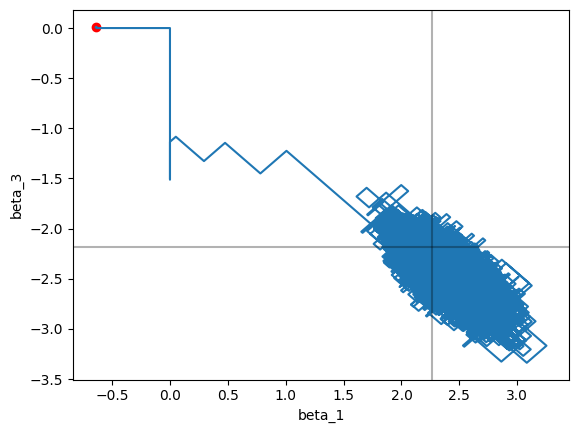

In [25]:
import matplotlib.pyplot as plt
Position = sampler.Position
i1 = 1
i2 = 3
plt.plot(Position[:,i1], Position[:,i2])
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)
plt.xlabel("beta_"+str(i1))
plt.ylabel("beta_"+str(i2))
plt.scatter(Position[0,i1], Position[0,i2],color="red")